## **Kuramoto Model Learned by SREINet**


## **I. Setup And Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 2


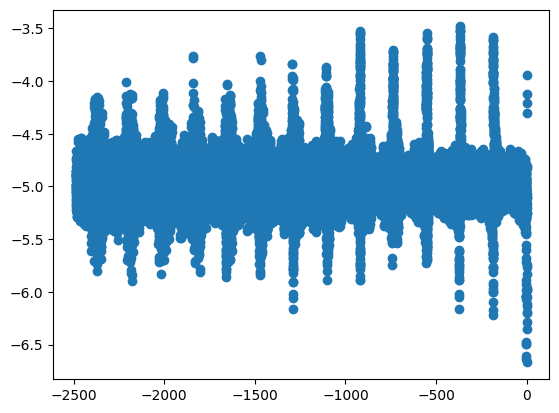

Training input shape: (50000, 60)
Training output shape: (50000, 60)


In [2]:
# Specify the model type
MY_MODEL = 'kuramoto' 
MY_DATA_TYPE = 'float32'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)


# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model type
DIM = 60  # You can change this value to your desired number of elements
num_traj = 10

data_initial_conditions = DG.DataGenerator.generate_initial_conditions(DIM, num_traj, seed=SEED) #np.random.normal(1, 2, LORENZ96_DIM

# Generate N random numbers from a normal distribution (mean=0, std=1)
#data_initial_conditions = np.random.normal(0, 1, DIM)
# wn: natrual frequency equally distributed within [-5,5]
wn = np.linspace(-5, 5, DIM)

data_T = 500.0       # Length of the data (T)
data_dt = 0.1     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, derivative_mode="exact")
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, wn, method='BDF')

print("Guess highest order polynomial:", guess_highest_order_polynomial)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.scatter(x_train[:,0], dx_train[:,0])
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.001

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[60, 60]


## **II. Model Training and Preparation**


### **2.1 Create the SREINet Model**


In [5]:
activation_fns = [
                 lambda x:tf.cos(x),
                 lambda x:tf.sin(x)]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 1, 
                     activations=activation_fns,
                    weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)



### **2.2 Loss Function**



In [6]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**



In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [8]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Pruning Schedule**

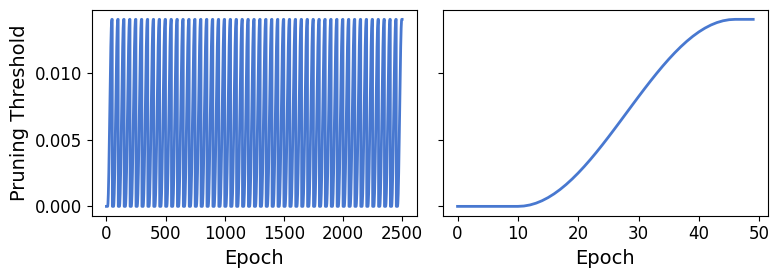

In [9]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.014
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 50
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    show_plot=True)


### Training

In [10]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.005 # Threshold for early stopping (Pruning Schedule Based)

training_histories = []
weights_list = []
loss_list = []
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 60
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 1.460e+00,  Validation Loss: 1.421e-01,  Epoch Time: 0.58s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 4.685e-02,  Validation Loss: 5.697e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 2.057e-02,  Validation Loss: 3.574e-02,  Epoch Time: 0.35s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 1.482e-02,  Validation Loss: 2.726e-02,  Epoch Time: 0.36s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 1.466e-02,  Validation Loss: 2.584e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 2.000e-02,  Validation Loss: 3.771e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 4.386e-02,  Validation Loss: 7.204e-02,  Epoch Time: 0.36s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 9.966e-02,  Validation Loss: 1.399e-01,  Epoc

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [21]:
def generate_LHS_labels(N):

    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    N = N//2
    return ['Constant'] + [f'cos(x{i})' for i in range(1, N+1)] + [f'sin(x{i})' for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [22]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [23]:
def combine_sine_cos_squared_terms(path_products):
    #post-processing of the summation of sin^2(x) and cos^2(x)
    #print(path_products)
    import re
    pattern = r'(\d+)\s+sin\(x\d+\)\^2'

    sin_squared_coeff = re.findall(r'([+-]?\s*\d+\.\d+|\d+)\*sin\(x\d+\)\^2', path_products[0])
    cos_squared_coeff = re.findall(r'([+-]?\s*\d+\.\d+|\d+)\*cos\(x\d+\)\^2', path_products[0])
    #convert to number array
    sin_squared_coeff = [float(i.replace(" ", "")) for i in sin_squared_coeff]
    cos_squared_coeff = [float(i.replace(" ", "")) for i in cos_squared_coeff]

    diff = np.abs(np.array(sin_squared_coeff) - np.array(cos_squared_coeff))
    #if one number is greater than 1e-4 report error
    if np.any(diff > 1e-3):
        print("Error: The coefficients of sin^2(x) and cos^2(x) are not equal.") 

    #remove sin and cos with their coefficients as well as the sign before coefficients from the path_products
    remaining = re.sub(r'([+-]?\s*\d+\.\d+|\d+)\*cos\(x\d+\)\^2', '', path_products[0])
    remaining = re.sub(r'([+-]?\s*\d+\.\d+|\d+)\*sin\(x\d+\)\^2', '', remaining)
    #sum sin coeffs
    extra_constant_by_sin_cos_squared = np.sum(sin_squared_coeff)

    # Search for the first match
    match = re.search(r'[-+]?\s*\d*\.\d+', remaining)
    # Print the first numerical value found
    if match:
        # Remove any leading/trailing spaces from the match
        first_number = match.group().strip()
        extra_constant = float(first_number.replace(" ", ""))
        final_constant = extra_constant + extra_constant_by_sin_cos_squared
        # add a space before the number if it is positive      
        if final_constant >0:
            final_constant_str = " " + str(final_constant)
        else:
            final_constant_str = str(final_constant)
        path_products_processed = re.sub(r'[-+]?\s*\d*\.\d+', final_constant_str, remaining, count=1)
    else:
        print("No number found.")
        path_products_processed = remaining

    
    #susbtitute the extra constant in path_products[0] by final_constant
    return [path_products_processed]


In [24]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    path_products = combine_sine_cos_squared_terms(path_products)

    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' =  -5.000001087790001 + 0.1999942511*sin(x1)  - 0.0333340615*cos(x1)*sin(x2) - 0.03333291784*cos(x1)*sin(x3) - 0.03333288059*cos(x1)*sin(x5) - 0.03333328478*cos(x1)*sin(x6) - 0.0333333388*cos(x1)*sin(x7) - 0.03333381005*cos(x1)*sin(x8) - 0.03333330527*cos(x1)*sin(x9) - 0.03333362378*cos(x1)*sin(x10) - 0.03333367035*cos(x1)*sin(x11) - 0.03333375789*cos(x1)*sin(x12) - 0.03333324939*cos(x1)*sin(x13) - 0.03333413973*cos(x1)*sin(x14) - 0.03333328664*cos(x1)*sin(x15) - 0.03333373368*cos(x1)*sin(x16) - 0.03333272785*cos(x1)*sin(x17) - 0.03333329782*cos(x1)*sin(x18) - 0.03333329596*cos(x1)*sin(x19) - 0.03333460912*cos(x1)*sin(x20) - 0.03333312832*cos(x1)*sin(x21) - 0.03333334625*cos(x1)*sin(x23) - 0.03333260678*cos(x1)*sin(x24) - 0.03333395347*cos(x1)*sin(x25) - 0.03333362937*cos(x1)*sin(x26) - 0.03333387524*cos(x1)*sin(x28) - 0.03333285637*cos(x1)*sin(x29) - 0.0333326105*cos(x1)*sin(x30) - 0.03333302215*cos(x1)*sin(x31) - 0.03333278932*cos(x1)*sin(x32) - 0.03333357722*cos(x1)*sin(x33) -

### **Validation**

In [15]:
import importlib

import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

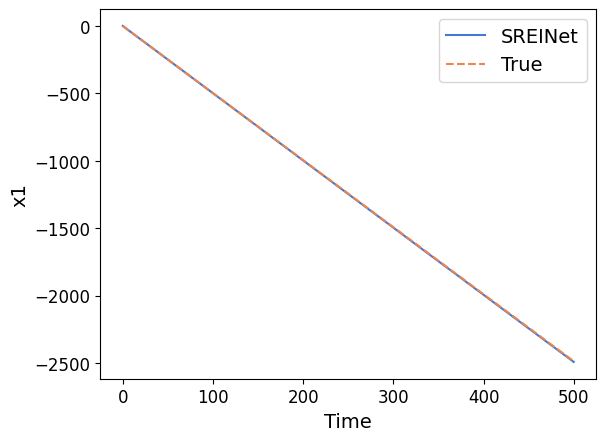

In [16]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()



In [17]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")


Score: 0.9999999999982333
Complexity: 7200


## **VI. Output**

In [18]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [19]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='lorenz96_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/lorenz96_nn_configurations.xlsx


In [20]:
from scipy.io import savemat
#concatenate t_arr, x_train, dx_train, and NN_output and save it as a mat file

#pate t_arr such that it has the same shape as x_train, dx_train, and NN_output

tem_t_arr = t_arr
for i in range(num_traj-1):
    tem_t_arr = np.concatenate((tem_t_arr, t_arr), axis=0) 
t_arr = tem_t_arr

m_data = np.concatenate((t_arr, x_train, dx_train, NN_output), axis=1)
savemat(os.path.join(opt_folder,'train_data.mat'), {'data': m_data})

v_data = np.concatenate((new_t_arr, new_x, new_dx, new_NN_output), axis=1)
savemat(os.path.join(opt_folder,'validation_data.mat'), {'data': v_data})

NameError: name 'NN_output' is not defined